<a href="https://colab.research.google.com/github/ZataraHere/Basic-Neural-Networks/blob/main/Pytorch_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Tensor Fundamentals***

In [1]:
import torch
torch.manual_seed(42)

**1.Creating Tensors**

In [2]:
x = torch.tensor([1,2,3])
zeros = torch.zeros(2,3)
ones = torch.ones(2,3)
random = torch.randn(2,3)


**2.Shape and Dimensions**

In [3]:
zeros.shape   # dimensions
x.dtype       # data type
x.device      # CPU vs GPU

device(type='cpu')

In [4]:
x = torch.randn(32, 3, 224, 224)
x.shape
x.ndim
x.numel()

4816896

**3. Indexing and Slicing**

In [5]:
x = torch.tensor([[1,2,3],
                  [4,5,6]])
x[0]
x[:,1]
x[:,:2]
x[0,1]

tensor(2)

**4. Tensor Operations**

In [6]:
a= torch.rand(1,4)
b = torch.rand(1,4)

a+b
a-b
a*b
a@b.T

a.mean()
a.sum()
a.max()

tensor(0.9028)

**5. Reshaping**

In [7]:
x = torch.tensor([[1,2,3,4],
                  [5,6,7,8]])

x.reshape(4,2)
x.flatten()
x.unsqueeze(0)
x.squeeze(0).shape
x.view(4,2)

y= x.permute(1,0)  # reorder dimensions


**6. CPU vs GPU**

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
x = torch.randn(100,100, device=device)

**7. Autograd**

In [9]:
#This is fundamental to neural network
x = torch.tensor(2.0, requires_grad=True)

y = x**2 + 3*x
y.backward()

print(x.grad)  # dy/dx = 2x + 3 = 7

tensor(7.)


# ***Tensor Operations & Broadcasting***

**1. Matrix Multiplication**

In [10]:
A = torch.randn(3, 4)
B = torch.randn(4, 5)

C = A @ B

print(C.shape)


torch.Size([3, 5])


In [11]:
torch.matmul(A, B)


tensor([[-0.6409, -0.5575,  1.2774, -1.9398,  2.3286],
        [ 0.6867,  0.4665,  3.0765, -0.2040,  1.2799],
        [-0.9619, -0.3628, -1.8532, -1.0048,  0.1680]])

In [12]:
C1 = A @ B
C2 = torch.matmul(A, B)

print(torch.allclose(C1, C2))
#For higher-dimensional tensors, torch.matmul also supports batched matrix multiplication.

True


**2. Broadcasting**

In [13]:
A = torch.tensor([
    [1],
    [2],
    [3]
])

B = torch.tensor([
    [10, 20, 30, 40]
])

print(A + B)


tensor([[11, 21, 31, 41],
        [12, 22, 32, 42],
        [13, 23, 33, 43]])


# ***Autograd Introduction***

In [14]:
#PyTorch's autograd system automatically computes derivatives of tensor operations.
import torch

x = torch.tensor(3.0, requires_grad=True)

y = x ** 2

y.backward()

print(x.grad)

tensor(6.)


In [15]:
x = torch.tensor(2.0, requires_grad=True)
#A tensor with requires_grad=False normally won't accumulate gradients.

y = x ** 3

y.backward()
print(x.grad)

tensor(12.)


In [16]:
x = torch.tensor(1.0, requires_grad=True)

y = torch.sin(x)

y.backward()

print("x =", x)
print("y =", y)
print("gradient =", x.grad)


x = tensor(1., requires_grad=True)
y = tensor(0.8415, grad_fn=<SinBackward0>)
gradient = tensor(0.5403)


**1. no_grad()**

In [17]:
x = torch.tensor(3.0, requires_grad=True)

with torch.no_grad():
    y = x ** 2

print(y.requires_grad)
#This is particularly useful during model inference/evaluation, when you don't need gradients

False


**2. .detach()**

In [18]:
#detach() creates a tensor that shares the underlying data but is disconnected from the current autograd graph.
x = torch.tensor(3.0, requires_grad=True)

y = x ** 2

z = y.detach()

print(y.requires_grad)
print(z.requires_grad)


True
False


**no_grad()                       vs           detach():
Controls a block of operations   |    Disconnects a particular tensor**

# ***Linear Regression from Scratch***

In [19]:
# Data
X = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0]
])

y = torch.tensor([
    [3.0],
    [5.0],
    [7.0],
    [9.0],
    [11.0]
])


In [20]:
class LinearRegressionfromScratch:
  def __init__(self):
    self.w = torch.randn(1, requires_grad= True)
    self.b = torch.tensor([0.0], requires_grad= True)

  def forward(self, X):
    return self.w * X + self.b

  def loss(self, y_pred, y):
    return ((y_pred - y)**2).mean()

  def train(self, X, y, epochs):
    for epoch in range(epochs):
      predictions = self.forward(X)
      loss = self.loss(predictions, y)
      loss.backward()
      with torch.no_grad():
        self.w-= 0.01*self.w.grad
        self.b -= 0.01*self.b.grad
      self.w.grad.zero_()
      self.b.grad.zero_()
      if (epoch+1)% 100 == 0:
        print(f"Epoch {epoch +1} :" f"Loss = {loss.item():.4f}")



In [21]:
clf= LinearRegressionfromScratch()
clf.train(X, y, 1000)

Epoch 100 :Loss = 0.0425
Epoch 200 :Loss = 0.0216
Epoch 300 :Loss = 0.0110
Epoch 400 :Loss = 0.0056
Epoch 500 :Loss = 0.0028
Epoch 600 :Loss = 0.0014
Epoch 700 :Loss = 0.0007
Epoch 800 :Loss = 0.0004
Epoch 900 :Loss = 0.0002
Epoch 1000 :Loss = 0.0001


**test the model**

In [22]:
with torch.no_grad():
    prediction = clf.forward(torch.tensor([[6.0]]))

print(prediction)

tensor([[13.0151]])


# ***NN Module Basic***

In [23]:
from torch import nn

# Data
X = torch.tensor([
    [1.0],
    [2.0],
    [3.0],
    [4.0],
    [5.0]
])

y = torch.tensor([
    [3.0],
    [5.0],
    [7.0],
    [9.0],
    [11.0]
])


**1. Build the model**

In [24]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


In [25]:
model = LinearRegression()

print(model)


LinearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


**2. Inspect model parameters**

In [26]:
for param in model.parameters():
    print(param)
# w and b

Parameter containing:
tensor([[0.2615]], requires_grad=True)
Parameter containing:
tensor([0.8452], requires_grad=True)


In [27]:
#Direct method
print("Weight:", model.linear.weight)
print("Bias:", model.linear.bias)


Weight: Parameter containing:
tensor([[0.2615]], requires_grad=True)
Bias: Parameter containing:
tensor([0.8452], requires_grad=True)


In [28]:
print(model.linear.weight.data)
print(model.linear.bias.data)


tensor([[0.2615]])
tensor([0.8452])


**3. Define loss and optimizer**

In [29]:
loss_fn = nn.MSELoss()  # Mean Squared Error function

In [30]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)
# Weight aur bias alag alag dene ki zarurat nhi h wo SGD khud identify kr lega

**4. Training Loop**

In [31]:
epochs  = 1000

for epoch in range(epochs):

  predictions = model(X)

  loss = loss_fn(predictions, y)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  if (epoch + 1) % 100 == 0:
        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 100: Loss = 0.0086
Epoch 200: Loss = 0.0044
Epoch 300: Loss = 0.0022
Epoch 400: Loss = 0.0011
Epoch 500: Loss = 0.0006
Epoch 600: Loss = 0.0003
Epoch 700: Loss = 0.0001
Epoch 800: Loss = 0.0001
Epoch 900: Loss = 0.0000
Epoch 1000: Loss = 0.0000


In [32]:
print("Weight:", model.linear.weight.item())
print("Bias:", model.linear.bias.item())

Weight: 1.9971572160720825
Bias: 1.010263204574585


**5. Test the model**

In [33]:
with torch.no_grad():
    prediction = model(torch.tensor([[6.0]]))

print(prediction)

tensor([[12.9932]])


# ***MNIST Data Pipeline***

In [34]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms    #Contains ready-to-use datasets such as: MNIST,CIFAR-10,Fashion-MNIST,ImageNet-related utilities
import matplotlib.pyplot as plt

**1. Define transformations**

In [43]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
# Provides image preprocessing operations.
# Compose lets us combine multiple transformations.

**2. Load MNIST dataset**

In [38]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.89MB/s]


**3. Create DataLoader**

In [39]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

**4. Get one batch**

In [40]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


**5. Visualize a batch**

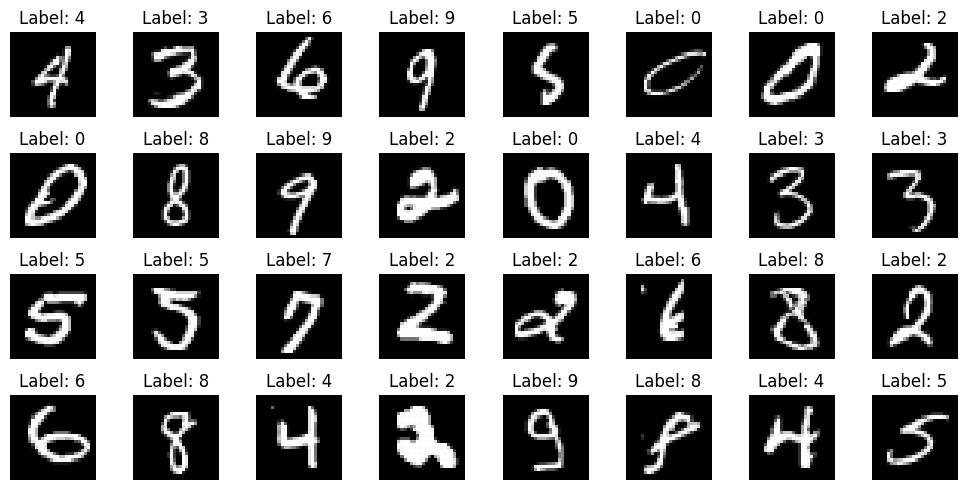

In [41]:
fig, axes = plt.subplots(4, 8, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    # Undo normalization for visualization
    image = images[i] * 0.3081 + 0.1307

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()